Instalação das Bibliotecas

In [ ]:
!pip install -q transformers datasets scikit-learn accelerate seaborn

Importações, configuração e reprodutibilidade

In [ ]:
import json
import os
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 512
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Dispositivo:", "cuda" if torch.cuda.is_available() else "cpu")
print("Modelo:", MODEL_NAME)
print("Seed:", SEED)


Dispositivo: cuda
Modelo: neuralmind/bert-base-portuguese-cased
Seed: 42


Download e organização do Fake.br-Corpus

In [ ]:
DATASET_URL = "https://github.com/roneysco/Fake.br-Corpus/archive/refs/heads/master.zip"
ZIP_PATH = Path("dataset.zip")
EXTRACT_DIR = Path("fake_br")

if not ZIP_PATH.exists():
    response = requests.get(DATASET_URL, timeout=120)
    response.raise_for_status()
    ZIP_PATH.write_bytes(response.content)

if not EXTRACT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

base_path = EXTRACT_DIR / "Fake.br-Corpus-master" / "full_texts"
fake_path = base_path / "fake"
true_path = base_path / "true"

records = []
for filename in sorted(fake_path.glob("*.txt")):
    records.append({"text": filename.read_text(encoding="utf-8"), "label": 1})
for filename in sorted(true_path.glob("*.txt")):
    records.append({"text": filename.read_text(encoding="utf-8"), "label": 0})

df = pd.DataFrame(records)
assert len(df) == 7200, f"Quantidade inesperada de registros: {len(df)}"
assert df["text"].notna().all()
assert set(df["label"].unique()) == {0, 1}

print(f"Total de notícias: {len(df)}")
print(df["label"].value_counts().sort_index().rename(index={0: "Real", 1: "Fake"}))
df.head()

Total de notícias: 7200
label
Real    3600
Fake    3600
Name: count, dtype: int64


,text,label
0,Kátia Abreu diz que vai colocar sua expulsão e...,1
1,"Dr. Ray peita Bolsonaro, chama-o de conservad...",1
2,Reinaldo Azevedo desmascarado pela Polícia Fed...,1
3,Relatório assustador do BNDES mostra dinheiro ...,1
4,"Radialista americano fala sobre o PT: ""Eles ve...",1


Versões

In [1]:
import sys
import platform
import json
import torch
import transformers
import datasets
import sklearn
import pandas
import numpy
import seaborn
import matplotlib
import accelerate

versoes_ambiente = {
    "python": sys.version,
    "sistema": platform.platform(),
    "pytorch": torch.__version__,
    "transformers": transformers.__version__,
    "datasets": datasets.__version__,
    "scikit_learn": sklearn.__version__,
    "pandas": pandas.__version__,
    "numpy": numpy.__version__,
    "seaborn": seaborn.__version__,
    "matplotlib": matplotlib.__version__,
    "accelerate": accelerate.__version__,
    "cuda_disponivel": torch.cuda.is_available(),
    "cuda_pytorch": torch.version.cuda,
}

if torch.cuda.is_available():
    versoes_ambiente["gpu"] = torch.cuda.get_device_name(0)
    versoes_ambiente["dispositivo"] = str(torch.device("cuda"))
else:
    versoes_ambiente["gpu"] = None
    versoes_ambiente["dispositivo"] = "cpu"

print(json.dumps(versoes_ambiente, indent=2, ensure_ascii=False))

with open("versoes_ambiente.json", "w", encoding="utf-8") as arquivo:
    json.dump(versoes_ambiente, arquivo, indent=2, ensure_ascii=False)


{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]",
  "sistema": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "pytorch": "2.11.0+cu128",
  "transformers": "5.16.1",
  "datasets": "4.0.0",
  "scikit_learn": "1.6.1",
  "pandas": "2.2.3",
  "numpy": "2.1.3",
  "seaborn": "0.13.2",
  "matplotlib": "3.10.0",
  "accelerate": "1.14.0",
  "cuda_disponivel": true,
  "cuda_pytorch": "12.8",
  "gpu": "Tesla T4",
  "dispositivo": "cuda"
}


Divisão estratificada em treinamento, validação e teste

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Tamanhos: treino =", len(train_df), "validação =", len(val_df), "teste =", len(test_df))
print("Distribuição por classe:")
print(pd.DataFrame({
    "treino": train_df["label"].value_counts().sort_index(),
    "validação": val_df["label"].value_counts().sort_index(),
    "teste": test_df["label"].value_counts().sort_index(),
}).rename(index={0: "Real", 1: "Fake"}))


Tamanhos: treino = 5760 validação = 720 teste = 720
Distribuição por classe:
       treino  validação  teste
label                          
Real     2880        360    360
Fake     2880        360    360


Tokenização

In [ ]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

def to_hf_dataset(frame):
    dataset = Dataset.from_pandas(frame[["text", "label"]], preserve_index=False)
    dataset = dataset.map(
        tokenize_function,
        batched=True,
        batch_size=32,
        remove_columns=["text"],
        writer_batch_size=32,
        desc="Tokenizando textos",
    )
    return dataset

train_dataset = to_hf_dataset(train_df)
val_dataset = to_hf_dataset(val_df)
test_dataset = to_hf_dataset(test_df)

y_true = test_df["label"].to_numpy(copy=True)

del df, temp_df, train_df, val_df, test_df
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Tokenização concluída com padding dinâmico.")

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizando textos:   0%|          | 0/5760 [00:00<?, ? examples/s]

Tokenizando textos:   0%|          | 0/720 [00:00<?, ? examples/s]

Tokenizando textos:   0%|          | 0/720 [00:00<?, ? examples/s]

Tokenização concluída com padding dinâmico.


Modelo, métricas e hiperparâmetros

In [ ]:
from transformers import DataCollatorWithPadding

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    accuracy = accuracy_score(labels, predictions)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir="./results_bertimbau",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs_bertimbau",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    seed=SEED,
    data_seed=SEED,
    report_to="none",
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    eval_accumulation_steps=8,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
)


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Fine-tuning usando somente o conjunto de validação para seleção

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print("Treinamento concluído.")
print("Melhor checkpoint:", trainer.state.best_model_checkpoint)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.127857,0.218077,0.966667,0.997041,0.936111,0.965616
2,0.091546,0.055391,0.990278,1.000000,0.980556,0.990182
3,0.053032,0.000771,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Treinamento concluído.
Melhor checkpoint: ./results_bertimbau/checkpoint-1080


Avaliação final do conjunto de teste

In [ ]:
test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="test")
prediction_output = trainer.predict(test_dataset, metric_key_prefix="test")
y_pred = prediction_output.predictions.argmax(axis=-1)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
final_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision,
    "recall": recall,
    "f1": f1,
}

print(json.dumps(final_metrics, indent=2, ensure_ascii=False))
print("\nRelatório por classe:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.053032,0.013479,3,0.998611,1.000000,0.997222,0.998609


{
  "accuracy": 0.9986111111111111,
  "precision": 1.0,
  "recall": 0.9972222222222222,
  "f1": 0.9986091794158554
}

Relatório por classe:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       360
        Fake       1.00      1.00      1.00       360

    accuracy                           1.00       720
   macro avg       1.00      1.00      1.00       720
weighted avg       1.00      1.00      1.00       720



Matriz de confusão e gráfico das métricas

Matriz de confusão [linhas = realidade; colunas = predição]:
 [[360   0]
 [  1 359]]


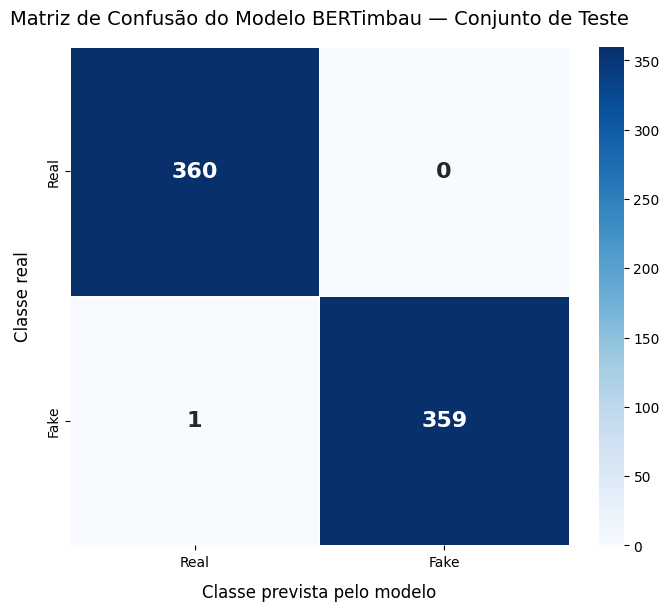

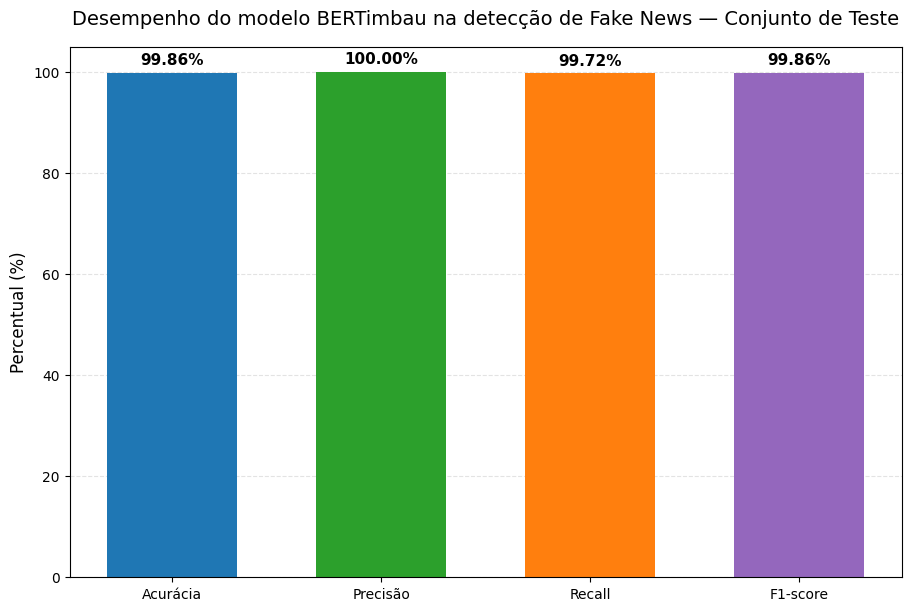

Figuras salvas como matriz_confusao_teste.png e metricas_teste.png


In [ ]:
# Gráfico 1 — matriz de confusão
# As linhas representam a classe real e as colunas representam a classe prevista.
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Matriz de confusão [linhas = realidade; colunas = predição]:\n", cm)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"],
    annot_kws={"fontsize": 16, "fontweight": "bold"},
    ax=ax,
)
ax.set_xlabel("Classe prevista pelo modelo", fontsize=12, labelpad=10)
ax.set_ylabel("Classe real", fontsize=12, labelpad=10)
ax.set_title("Matriz de Confusão do Modelo BERTimbau — Conjunto de Teste", fontsize=14, pad=16)
fig.savefig("matriz_confusao_teste.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Gráfico 2 — métricas finais
metric_names = ["Acurácia", "Precisão", "Recall", "F1-score"]
metric_keys = ["accuracy", "precision", "recall", "f1"]
metric_values = [final_metrics[key] * 100 for key in metric_keys]

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd"]
bars = ax.bar(metric_names, metric_values, color=colors, width=0.62)
ax.set_ylim(0, 105)
ax.set_ylabel("Percentual (%)", fontsize=12)
ax.set_title("Desempenho do modelo BERTimbau na detecção de Fake News — Conjunto de Teste", fontsize=14, pad=16)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.0,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

fig.savefig("metricas_teste.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Figuras salvas como matriz_confusao_teste.png e metricas_teste.png")



Registro da configuração e dos resultados

In [ ]:
from pathlib import Path
import json

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "train_size": len(train_dataset),
    "validation_size": len(val_dataset),
    "test_size": len(test_dataset),
    "num_train_epochs": 3,
    "train_batch_size": training_args.per_device_train_batch_size,
    "eval_batch_size": training_args.per_device_eval_batch_size,
    "gradient_accumulation_steps": training_args.gradient_accumulation_steps,
    "learning_rate": 5e-5,
    "warmup_steps": 500,
    "weight_decay": 0.01,
    "device": str(training_args.device),
    "torch_version": torch.__version__,
}

Path("experimento_config.json").write_text(
    json.dumps(config, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

Path("resultados_finais.json").write_text(
    json.dumps(final_metrics, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Configuração e resultados salvos com sucesso.")
print(json.dumps(config, indent=2, ensure_ascii=False))
print(json.dumps(final_metrics, indent=2, ensure_ascii=False))


Configuração e resultados salvos com sucesso.
{
  "seed": 42,
  "model_name": "neuralmind/bert-base-portuguese-cased",
  "max_length": 512,
  "train_size": 5760,
  "validation_size": 720,
  "test_size": 720,
  "num_train_epochs": 3,
  "train_batch_size": 4,
  "eval_batch_size": 4,
  "gradient_accumulation_steps": 4,
  "learning_rate": 5e-05,
  "warmup_steps": 500,
  "weight_decay": 0.01,
  "device": "cuda:0",
  "torch_version": "2.11.0+cu128"
}
{
  "accuracy": 0.9986111111111111,
  "precision": 1.0,
  "recall": 0.9972222222222222,
  "f1": 0.9986091794158554
}
